# Projet P11 - Notebook 1
## Notebook 1 — Préparation, Nettoyage et Exploration des données
### Étude de marché internationale — Expansion export volaille bio

---

## Contexte
La Poule qui Chante est une entreprise française d'agroalimentaire spécialisée dans
l'élevage et la vente de poulets sous le label **"Poulet Agriculture Biologique"**.

L'objectif de ce notebook est de **préparer et nettoyer les données** nécessaires
à l'identification des pays cibles pour l'export de poulet bio français.

---

### Objectifs
- charger les sources disponibles ;
- construire une table pays exploitable pour 2017 ;
- créer plusieurs variables métier utiles à la suite ;
- ajouter quelques indicateurs dynamiques 2013-2017 pour mieux anticiper la demande ;
- exporter un dataset propre pour l'ACP et le clustering.


## Lexique des variables

### Variables d'identification et contexte

- `pays` : nom du pays retenu dans le dataset final.
- `iso3` : code pays ISO à 3 lettres.
- `continent` : continent de rattachement selon CEPII.
- `landlocked` : indicateur binaire, `1` si le pays est enclave, `0` sinon.
- `distance_france_km` : distance CEPII entre la France et le pays cible.

### Démographie et urbanisation

- `population_totale` : population totale du pays.
- `population_milliers` : population totale exprimée en milliers d'habitants.
- `croissance_population_pct` : croissance annuelle moyenne de la population entre 2013 et 2017.
- `pct_population_urbaine` : part de la population vivant en zone urbaine en 2017.
- `croissance_population_urbaine_pct` : croissance annuelle moyenne de la population urbaine entre 2013 et 2017.
- `variation_part_urbaine_points` : évolution de la part urbaine entre 2013 et 2017, en points.

### Marche de la volaille et consommation

- `volaille_kcal_hab_jour` : apport quotidien en calories provenant de la viande de volaille par habitant.
- `volaille_kg_hab_an` : quantité annuelle de viande de volaille disponible pour la consommation par habitant.
- `viande_totale_kg_hab_an` : quantité annuelle totale de viande disponible pour la consommation par habitant.
- `volaille_production_tonnes` : production nationale de viande de volaille.
- `marche_volaille_tonnes` : proxy de la taille du marché intérieur de la volaille, basé sur la disponibilité intérieure.
- `volaille_import_tonnes` : volume importé de viande de volaille selon les bilans alimentaires FAO.
- `volaille_disponibilite_tonnes` : disponibilité intérieure totale de viande de volaille.
- `proteines_volaille_g_hab_jour` : apport quotidien en protéines provenant de la viande de volaille par habitant.
- `proteines_viande_totale_g_hab_jour` : apport quotidien total en protéines provenant de la viande par habitant.
- `croissance_conso_volaille_pct` : croissance annuelle moyenne de la consommation de volaille par habitant entre 2013 et 2017.
- `croissance_import_volaille_pct` : croissance annuelle moyenne des importations de volaille entre 2013 et 2017.

### Commerce volaille détaillé

- `volaille_import_quantite_trade_tonnes` : quantité de viande de volaille importée en 2017 d'après les statistiques de commerce FAO.
- `volaille_export_quantite_trade_tonnes` : quantité de viande de volaille exportée en 2017 d'après les statistiques de commerce FAO.
- `volaille_import_valeur_kusd` : valeur des importations de viande de volaille en 2017, en milliers de dollars US.
- `volaille_export_valeur_kusd` : valeur des exportations de viande de volaille en 2017, en milliers de dollars US.
- `prix_moyen_import_volaille_usd_tonne` : prix moyen à l'importation de la viande de volaille, calculé à partir des valeurs et quantités de commerce.
- `prix_moyen_export_volaille_usd_tonne` : prix moyen à l'exportation de la viande de volaille, calculé à partir des valeurs et quantités de commerce.

### Sécurité alimentaire et abordabilité

- `proteines_animales_g_hab_jour` : disponibilités moyennes de protéines d'origine animale, en g/personne/jour, sur la période 2015-2017.
- `sous_alimentation_pct` : prévalence moyenne de la sous-alimentation, en pourcentage, sur la période 2015-2017.
- `suffisance_apports_energetiques_pct` : suffisance moyenne des apports énergétiques alimentaires, en pourcentage, sur la période 2015-2017.
- `cout_alimentation_saine_ppp_jour` : coût d'une alimentation saine en 2017, exprimé en dollars internationaux PPA par personne et par jour.
- `prevalence_inabordabilite_alimentation_saine_pct` : part de la population ne pouvant pas s'offrir une alimentation saine en 2017.
- `nua_millions` : nombre de personnes, en millions, n'ayant pas les moyens de s'alimenter sainement en 2017.

### Macro-économie et commerce général

- `pib_hab_ppp` : PIB par habitant en parité de pouvoir d'achat.
- `croissance_pib_pct` : croissance annuelle du PIB.
- `imports_alimentaires_pct` : poids des importations alimentaires dans les importations de marchandises.
- `importations_marchandises_usd` : valeur totale des importations de marchandises.
- `exportations_marchandises_usd` : valeur totale des exportations de marchandises.

### Logistique et accessibilité

- `lpi_douane` : efficacité du passage en douane selon le Logistics Performance Index.
- `lpi_infrastructure` : qualité des infrastructures de transport et de commerce selon le LPI.
- `delai_import_jours` : délai médian d'importation.
- `delai_export_jours` : délai médian d'exportation.
- `connectivite_maritime` : niveau de connectivité maritime du pays.

### Gouvernance et stabilité politique

- `score_stabilite_politique` : score WGI de stabilité politique et d'absence de violence, sur 100.
- `score_efficacite_gouvernement` : score WGI d'efficacité gouvernementale, sur 100.
- `score_qualite_reglementaire` : score WGI de qualité de la réglementation, sur 100.
- `score_etat_droit` : score WGI d'état de droit, sur 100.
- `score_controle_corruption` : score WGI de contrôle de la corruption, sur 100.
- `indice_gouvernance_moyen` : moyenne simple des scores WGI retenus.

### Variables créées pour l'analyse

- `taux_dependance_import` : part de la disponibilité intérieure couverte par les importations.
- `part_volaille_dans_consommation_viande` : poids de la volaille dans la consommation totale de viande.
- `part_proteines_volaille_dans_viandes` : poids de la volaille dans les protéines issues de la viande


In [1]:
from pathlib import Path
import sys #environnement système 

import matplotlib.pyplot as plt #graphs
import numpy as np #objets num -> numpy
import pandas as pd #dataframes
import pycountry
import seaborn as sns #graphs

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.p11_utils import add_iso3

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

FBS_PATH = DATA_DIR / 'FoodBalanceSheets_E_All_Data_(Normalized)' / 'FoodBalanceSheets_E_All_Data_(Normalized).csv'
WDI_PATH = DATA_DIR / 'P_Data_Extract_From_World_Development_Indicators.xlsx'
POPULATION_PATH = DATA_DIR / 'Population_2000_2018.csv'
WGI_PATH = DATA_DIR / 'wgidataset_with_sourcedata-2025.xlsx'
TRADE_PATH = DATA_DIR / 'Commerce_CultureProduitsAnimaux_F_Toutes_les_Données_(Normalisé)' / 'Commerce_CultureProduitsAnimaux_F_Toutes_les_Données_(Normalisé).csv'
FOOD_SECURITY_PATH = DATA_DIR / 'Données_de_la_sécurité_alimentaire_F_Toutes_les_Données_(Normalisé)' / 'Données_de_la_sécurité_alimentaire_F_Toutes_les_Données_(Normalisé).csv'
COAHD_PATH = DATA_DIR / 'Cout_abordabilite_alimentation_saine_(CoAHD)_F_Toutes_les_Données_(Normalisé)' / 'Cout_abordabilite_alimentation_saine_(CoAHD)_F_Toutes_les_Données_(Normalisé).csv'
GEO_PATH = ROOT / 'geo_cepii.xls'
DIST_PATH = ROOT / 'dist_cepii.xls'

YEAR = 2017
FBS_VARIABLES = [
    ('Poultry Meat', 'Food supply (kcal/capita/day)', 'volaille_kcal_hab_jour'),
    ('Poultry Meat', 'Food supply quantity (kg/capita/yr)', 'volaille_kg_hab_an'),
    ('Poultry Meat', 'Production', 'volaille_production_tonnes'),
    ('Poultry Meat', 'Import quantity', 'volaille_import_tonnes'),
    ('Poultry Meat', 'Domestic supply quantity', 'volaille_disponibilite_tonnes'),
    ('Poultry Meat', 'Protein supply quantity (g/capita/day)', 'proteines_volaille_g_hab_jour'),
    ('Meat', 'Food supply quantity (kg/capita/yr)', 'viande_totale_kg_hab_an'),
    ('Meat', 'Protein supply quantity (g/capita/day)', 'proteines_viande_totale_g_hab_jour'),
]

WDI_VARIABLES = {
    'Population, total': 'population_totale',
    'GDP per capita, PPP (current international $)': 'pib_hab_ppp',
    'GDP growth (annual %)': 'croissance_pib_pct',
    'Urban population (% of total population)': 'pct_population_urbaine',
    'Food imports (% of merchandise imports)': 'imports_alimentaires_pct',
    'Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)': 'lpi_douane',
    'Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)': 'lpi_infrastructure',
    'Lead time to import, median case (days)': 'delai_import_jours',
    'Lead time to export, median case (days)': 'delai_export_jours',
    'Liner shipping connectivity index (maximum value in 2004 = 100)': 'connectivite_maritime',
    'Merchandise imports (current US$)': 'importations_marchandises_usd',
    'Merchandise exports (current US$)': 'exportations_marchandises_usd',
}

WDI_FALLBACKS = {
    'Logistics performance index: Efficiency of customs clearance process (1=low to 5=high)': ('mean', [2016, 2018]),
    'Logistics performance index: Quality of trade and transport-related infrastructure (1=low to 5=high)': ('mean', [2016, 2018]),
    'Lead time to import, median case (days)': ('coalesce', [2017, 2018, 2016]),
    'Lead time to export, median case (days)': ('coalesce', [2017, 2018, 2016]),
}

WGI_SHEETS = {
    'pv': 'score_stabilite_politique',
    'ge': 'score_efficacite_gouvernement',
    'rq': 'score_qualite_reglementaire',
    'rl': 'score_etat_droit',
    'cc': 'score_controle_corruption',
}

MODELING_FEATURES = [
    'volaille_kcal_hab_jour',
    'volaille_kg_hab_an',
    'volaille_production_tonnes',
    'volaille_import_tonnes',
    'volaille_disponibilite_tonnes',
    'pib_hab_ppp',
    'croissance_pib_pct',
    'pct_population_urbaine',
    'imports_alimentaires_pct',
    'lpi_douane',
    'lpi_infrastructure',
    'delai_import_jours',
    'connectivite_maritime',
    'distance_france_km',
    'croissance_population_pct',
    'croissance_population_urbaine_pct',
    'variation_part_urbaine_points',
    'croissance_conso_volaille_pct',
    'croissance_import_volaille_pct',
    'prix_moyen_import_volaille_usd_tonne',
    'proteines_animales_g_hab_jour',
    'sous_alimentation_pct',
    'cout_alimentation_saine_ppp_jour',
    'prevalence_inabordabilite_alimentation_saine_pct',
    'score_stabilite_politique',
    'indice_gouvernance_moyen',
    'marche_volaille_tonnes',
    'taux_dependance_import',
    'part_volaille_dans_consommation_viande',
    'part_proteines_volaille_dans_viandes',
]

## Sources de données

### Sources utilisées dans le dataset final

- `FoodBalanceSheets_E_All_Data_(Normalized)` : consommation, production, importations, disponibilités alimentaires et protéines sur la volaille et la viande.
- `P_Data_Extract_From_World_Development_Indicators.xlsx` : population, PIB, urbanisation, logistique et commerce.
- `Population_2000_2018.csv` : historique de population utilisé pour les taux de croissance 2013-2017.
- `wgidataset_with_sourcedata-2025.xlsx` : gouvernance et stabilité politique via les indicateurs WGI.
- `Commerce_CultureProduitsAnimaux_F_Toutes_les_Données_(Normalisé)` : quantités, valeurs et prix moyens à l'import et à l'export sur la viande de volaille.
- `Données_de_la_sécurité_alimentaire_F_Toutes_les_Données_(Normalisé)` : disponibilité de protéines animales, sous-alimentation et suffisance énergétique.
- `Cout_abordabilite_alimentation_saine_(CoAHD)_F_Toutes_les_Données_(Normalisé)` : coût d'une alimentation saine et indicateurs d'inabordabilité alimentaire.
- `geo_cepii.xls` : continent et statut enclavé.
- `dist_cepii.xls` : distance entre la France et les pays cibles.

### Sources complémentaires disponibles dans le projet

- `Commerce_CultureProduitsAnimauxIndicatuers_F_Toutes_les_Données_(Normalisé)`
- `Commerce_MatricesCommerceDetaillees_F_Toutes_les_Données_(Normalisé)`
- `Statistiques-macro_Indicateurs_clés_F_Toutes_les_Données_(Normalisé)`
- `data/donnees_complementaires` : fichiers FAO conservés localement comme référence complémentaire sur la structure alimentaire et les protéines.

Cette section permet de distinguer les sources déjà intégrées au pipeline des sources encore disponibles pour enrichir l'analyse dans une étape ultérieure.

In [2]:
available_sources = sorted([p.name for p in DATA_DIR.iterdir()])
available_sources

['Commerce_CultureProduitsAnimauxIndicatuers_F_Toutes_les_Données_(Normalisé)',
 'Commerce_CultureProduitsAnimaux_F_Toutes_les_Données_(Normalisé)',
 'Commerce_MatricesCommerceDetaillees_F_Toutes_les_Données_(Normalisé)',
 'Cout_abordabilite_alimentation_saine_(CoAHD)_F_Toutes_les_Données_(Normalisé)',
 'DisponibiliteAlimentaire_2017.csv',
 'Données_de_la_sécurité_alimentaire_F_Toutes_les_Données_(Normalisé)',
 'FoodBalanceSheets_E_All_Data_(Normalized)',
 'P_Data_Extract_From_World_Development_Indicators (1).xlsx',
 'P_Data_Extract_From_World_Development_Indicators.xlsx',
 'Population_2000_2018.csv',
 'Statistiques-macro_Indicateurs_clés_F_Toutes_les_Données_(Normalisé)',
 'bio',
 'donnees_complementaires',
 'wgidataset_with_sourcedata-2025.xlsx']

## Références FAO complémentaires

Des fichiers FAO complémentaires sont conservés localement dans `data/donnees_complementaires` comme **référence de lecture** sur la structure alimentaire et les protéines.

Ils ne servent pas de source principale dans le pipeline P11, mais ils restent utiles pour :
- recouper certains libellés FAO ;
- retrouver une lecture par produit et par origine alimentaire ;
- documenter certains choix de variables de consommation.

## 1. Construction du dataset pays

La base finale combine :
- la FAO pour la volaille et la consommation alimentaire ;
- la Banque mondiale pour les variables macro, logistiques et urbaines ;
- CEPII pour la distance à la France et le statut enclave ;
- des indicateurs dynamiques 2013-2017 pour ajouter une lecture d'évolution de la demande.


In [3]:
def compute_cagr(start, end, periods=4):
    start = pd.to_numeric(start, errors='coerce')
    end = pd.to_numeric(end, errors='coerce')
    return np.where((start > 0) & (end > 0), ((end / start) ** (1 / periods) - 1) * 100, np.nan)


def m49_to_iso3(value):
    if pd.isna(value):
        return None
    digits = ''.join(ch for ch in str(value) if ch.isdigit())
    if not digits:
        return None
    country = pycountry.countries.get(numeric=digits.zfill(3))
    return country.alpha_3 if country else None


def add_source_iso3(df, m49_col='Code zone (M49)', zone_col='Zone'):
    """Combine le mapping M49 et le nom du pays pour recuperer un iso3 quand c'est possible."""
    result = df.copy()
    result['iso3'] = result[m49_col].map(m49_to_iso3)
    if zone_col in result.columns:
        zone_iso = add_iso3(result[[zone_col]].copy(), zone_col)['iso3']
        result['iso3'] = result['iso3'].fillna(zone_iso)
    return result


def parse_food_security_value(value):
    """Transforme les valeurs censurees du type '<2.5' en borne numerique 2.5."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.startswith('<'):
        text = text[1:].strip()
    if text == '':
        return np.nan
    return pd.to_numeric(text, errors='coerce')


fbs = pd.read_csv(FBS_PATH, encoding='latin-1')
fbs = add_iso3(fbs, 'Area')
fbs['Value'] = pd.to_numeric(fbs['Value'], errors='coerce')
fbs_2017 = fbs[(fbs['Year'] == YEAR) & fbs['iso3'].notna()].copy()

frames = []
for item, element, new_name in FBS_VARIABLES:
    temp = fbs_2017.loc[
        (fbs_2017['Item'] == item) & (fbs_2017['Element'] == element),
        ['iso3', 'Area', 'Value'],
    ].copy()
    temp = temp.rename(columns={'Area': 'pays_fao', 'Value': new_name})
    frames.append(temp.drop_duplicates(subset=['iso3']))

df_fbs = frames[0]
for frame in frames[1:]:
    # outer : on construit d'abord une base FAO la plus large possible sans perdre un pays
    # simplement parce qu'une variable volaille manque dans une des briques initiales.
    df_fbs = df_fbs.merge(frame.drop(columns=['pays_fao']), on='iso3', how='outer')

# Indicateurs dynamiques FAO 2013-2017
fbs_dynamic = fbs.loc[
    fbs['iso3'].notna()
    & fbs['Year'].isin([2013, 2017])
    & (fbs['Item'] == 'Poultry Meat')
    & (fbs['Element'].isin(['Food supply quantity (kg/capita/yr)', 'Import quantity'])),
    ['iso3', 'Year', 'Element', 'Value'],
].copy()
fbs_dynamic = fbs_dynamic.pivot_table(index='iso3', columns=['Element', 'Year'], values='Value', aggfunc='first')
fbs_dynamic.columns = [f'{element}_{year}' for element, year in fbs_dynamic.columns]
fbs_dynamic = fbs_dynamic.reset_index()
fbs_dynamic['croissance_conso_volaille_pct'] = compute_cagr(
    fbs_dynamic.get('Food supply quantity (kg/capita/yr)_2013'),
    fbs_dynamic.get('Food supply quantity (kg/capita/yr)_2017'),
)
fbs_dynamic['croissance_import_volaille_pct'] = compute_cagr(
    fbs_dynamic.get('Import quantity_2013'),
    fbs_dynamic.get('Import quantity_2017'),
)
fbs_dynamic = fbs_dynamic[['iso3', 'croissance_conso_volaille_pct', 'croissance_import_volaille_pct']]

wdi = pd.read_excel(WDI_PATH, sheet_name='Data')
subset = wdi[wdi['Series Name'].isin(WDI_VARIABLES.keys())].copy()
df_wdi = subset[['Country Name', 'Country Code']].drop_duplicates()
df_wdi = df_wdi.rename(columns={'Country Name': 'pays_wdi', 'Country Code': 'iso3'})

for series_name, output_name in WDI_VARIABLES.items():
    mode, years = WDI_FALLBACKS.get(series_name, ('coalesce', [YEAR]))
    cols = [f'{current_year} [YR{current_year}]' for current_year in years]
    temp = subset.loc[subset['Series Name'] == series_name, ['Country Code'] + cols].copy()
    for col in cols:
        temp[col] = pd.to_numeric(temp[col], errors='coerce')
    if mode == 'mean':
        temp[output_name] = temp[cols].mean(axis=1)
    else:
        temp[output_name] = temp[cols].bfill(axis=1).iloc[:, 0]
    df_wdi = df_wdi.merge(
        temp[['Country Code', output_name]].rename(columns={'Country Code': 'iso3'}),
        on='iso3',
        # left : on garde tous les pays déjà présents dans la base WDI, même si une
        # série particulière manque pour certains d'entre eux.
        how='left',
    )

# Indicateurs dynamiques WDI 2013-2017
wdi_dynamic_specs = {
    'Urban population': 'population_urbaine',
    'Urban population (% of total population)': 'part_urbaine',
}
wdi_dynamic = wdi[['Country Code']].drop_duplicates().rename(columns={'Country Code': 'iso3'})
for series_name, prefix in wdi_dynamic_specs.items():
    cols = ['2013 [YR2013]', '2017 [YR2017]']
    temp = wdi.loc[wdi['Series Name'] == series_name, ['Country Code'] + cols].copy()
    for col in cols:
        temp[col] = pd.to_numeric(temp[col], errors='coerce')
    temp = temp.rename(columns={'Country Code': 'iso3', '2013 [YR2013]': f'{prefix}_2013', '2017 [YR2017]': f'{prefix}_2017'})
    wdi_dynamic = wdi_dynamic.merge(
        temp,
        on='iso3',
        # left : on préserve le périmètre pays de la table dynamique WDI, même si
        # une des deux séries urbaines est absente.
        how='left',
    )

wdi_dynamic['croissance_population_urbaine_pct'] = compute_cagr(
    wdi_dynamic['population_urbaine_2013'],
    wdi_dynamic['population_urbaine_2017'],
)
wdi_dynamic['variation_part_urbaine_points'] = wdi_dynamic['part_urbaine_2017'] - wdi_dynamic['part_urbaine_2013']
wdi_dynamic = wdi_dynamic[['iso3', 'croissance_population_urbaine_pct', 'variation_part_urbaine_points']]

population = pd.read_csv(POPULATION_PATH, encoding='utf-8-sig')
population = add_iso3(population, 'Zone')
population['Valeur'] = pd.to_numeric(population['Valeur'], errors='coerce')
pop_growth = population.loc[
    (population['Élément'] == 'Population totale') & population['iso3'].notna(),
    ['iso3', 'Année', 'Valeur'],
].copy()
pop_growth['Année'] = pd.to_numeric(pop_growth['Année'], errors='coerce')
pop_growth = pop_growth.pivot_table(index='iso3', columns='Année', values='Valeur', aggfunc='first')
pop_growth = (((pop_growth[2017] / pop_growth[2013]) ** (1 / 4)) - 1) * 100
pop_growth = pop_growth.rename('croissance_population_pct').reset_index()

# Fallback WDI : le fichier population OC couvre mal certains pays du périmètre final.
# On complète donc la croissance de population avec la série WDI 'Population, total'
# calculée sur la même période 2013-2017 quand la source principale est manquante.

wdi_population = wdi.loc[wdi['Series Name'] == 'Population, total', ['Country Code', '2013 [YR2013]', '2017 [YR2017]']].copy()
for col in ['2013 [YR2013]', '2017 [YR2017]']:
    wdi_population[col] = pd.to_numeric(wdi_population[col], errors='coerce')
wdi_population['croissance_population_pct_wdi'] = compute_cagr(
    wdi_population['2013 [YR2013]'],
    wdi_population['2017 [YR2017]'],
)
pop_growth = pop_growth.merge(
    wdi_population[['Country Code', 'croissance_population_pct_wdi']].rename(columns={'Country Code': 'iso3'}),
    on='iso3',
    how='outer',
)
pop_growth['croissance_population_pct'] = pop_growth['croissance_population_pct'].fillna(pop_growth['croissance_population_pct_wdi'])
pop_growth = pop_growth[['iso3', 'croissance_population_pct']]

# Gouvernance mondiale (WGI) en 2017
wgi_frames = []
for sheet_name, output_name in WGI_SHEETS.items():
    temp = pd.read_excel(
        WGI_PATH,
        sheet_name=sheet_name,
        usecols=['Economy (name)', 'Economy (code)', 'Year', 'Governance score (0-100)'],
    )
    temp = temp.loc[temp['Year'] == YEAR, ['Economy (name)', 'Economy (code)', 'Governance score (0-100)']].copy()
    temp = temp.rename(columns={
        'Economy (name)': 'pays_wgi',
        'Economy (code)': 'iso3',
        'Governance score (0-100)': output_name,
    })
    wgi_frames.append(temp.drop_duplicates(subset=['iso3']))

df_wgi = wgi_frames[0]
for frame in wgi_frames[1:]:
    # outer : on assemble les dimensions WGI sans exclure un pays qui serait présent
    # sur une dimension et manquant sur une autre.
    df_wgi = df_wgi.merge(frame.drop(columns=['pays_wgi']), on='iso3', how='outer')

governance_cols = list(WGI_SHEETS.values())
df_wgi['indice_gouvernance_moyen'] = df_wgi[governance_cols].mean(axis=1)

# Commerce volaille detaille en 2017
trade_chunks = []
trade_usecols = ['Code zone (M49)', 'Zone', 'Produit', 'Élément', 'Année', 'Valeur']
trade_products_priority = {'Viande de Volailles': 0, 'Viande de Volaille': 1}
trade_elements = {
    'Importations - quantité': 'volaille_import_quantite_trade_tonnes',
    'Importations - valeur': 'volaille_import_valeur_kusd',
    'Exportations - quantité': 'volaille_export_quantite_trade_tonnes',
    'Exportations - valeur': 'volaille_export_valeur_kusd',
}
for chunk in pd.read_csv(TRADE_PATH, encoding='utf-8', usecols=trade_usecols, chunksize=200000, low_memory=False):
    sub = chunk.loc[
        (chunk['Année'] == YEAR)
        & (chunk['Produit'].isin(trade_products_priority.keys()))
        & (chunk['Élément'].isin(trade_elements.keys())),
        trade_usecols,
    ].copy()
    if not sub.empty:
        trade_chunks.append(sub)

trade = pd.concat(trade_chunks, ignore_index=True)
trade['iso3'] = trade['Code zone (M49)'].map(m49_to_iso3)
trade['Valeur'] = pd.to_numeric(trade['Valeur'], errors='coerce')
trade['product_rank'] = trade['Produit'].map(trade_products_priority)
trade = trade[trade['iso3'].notna()].sort_values(['iso3', 'Élément', 'product_rank'])
trade = trade.drop_duplicates(subset=['iso3', 'Élément'], keep='first')
df_trade = trade.pivot_table(index='iso3', columns='Élément', values='Valeur', aggfunc='first').reset_index()
df_trade = df_trade.rename(columns=trade_elements)
df_trade['prix_moyen_import_volaille_usd_tonne'] = np.where(
    df_trade['volaille_import_quantite_trade_tonnes'] > 0,
    (df_trade['volaille_import_valeur_kusd'] * 1000) / df_trade['volaille_import_quantite_trade_tonnes'],
    np.nan,
)
df_trade['prix_moyen_export_volaille_usd_tonne'] = np.where(
    df_trade['volaille_export_quantite_trade_tonnes'] > 0,
    (df_trade['volaille_export_valeur_kusd'] * 1000) / df_trade['volaille_export_quantite_trade_tonnes'],
    np.nan,
)

# Sécurité alimentaire (moyenne 2015-2017)
food_security = pd.read_csv(FOOD_SECURITY_PATH, encoding='utf-8', usecols=['Code zone (M49)', 'Zone', 'Produit', 'Élément', 'Année', 'Valeur'], low_memory=False)
food_security = add_source_iso3(food_security)
# Certaines valeurs FAO sont publiées sous forme censurée ('<2.5').
# On les convertit en borne numérique pour conserver l'information plutôt que de la perdre.
food_security['Valeur'] = food_security['Valeur'].map(parse_food_security_value)
food_security_targets = {
    'Disponibilités protéines moyennes d’origine animale (g/personne/jour) (moyenne sur 3 ans)': 'proteines_animales_g_hab_jour',
    'Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)': 'sous_alimentation_pct',
    'Suffisance des apports énergétiques alimentaires moyens (%) (moyenne sur 3 ans)': 'suffisance_apports_energetiques_pct',
}
food_security = food_security.loc[
    food_security['iso3'].notna()
    & (food_security['Élément'] == 'Valeur')
    & (food_security['Année'] == '2015-2017')
    & (food_security['Produit'].isin(food_security_targets.keys())),
    ['iso3', 'Produit', 'Valeur'],
].copy()
df_food_security = food_security.pivot_table(index='iso3', columns='Produit', values='Valeur', aggfunc='first').reset_index()
df_food_security = df_food_security.rename(columns=food_security_targets)

# Cout et inabordabilité d'une alimentation saine en 2017
coahd = pd.read_csv(COAHD_PATH, encoding='utf-8', usecols=['Code zone (M49)', 'Zone', 'Produit', 'Élément', 'Année', 'Valeur'], low_memory=False)
coahd = add_source_iso3(coahd)
coahd['Valeur'] = pd.to_numeric(coahd['Valeur'], errors='coerce')
coahd['Année'] = pd.to_numeric(coahd['Année'], errors='coerce')
coahd_targets = {
    'Coût d’une alimentation saine (CoHD)': 'cout_alimentation_saine_ppp_jour',
    'Prévalence de l’inabordabilité d’une alimentation saine (PUA)': 'prevalence_inabordabilite_alimentation_saine_pct',
    'Nombre de personnes n’ayant pas les moyens de s’alimenter sainement (NUA)': 'nua_millions',
}
coahd_target_2017 = coahd.loc[
    coahd['iso3'].notna()
    & (coahd['Élément'] == 'Valeur')
    & (coahd['Année'] == YEAR)
    & (coahd['Produit'].isin(coahd_targets.keys())),
    ['iso3', 'Produit', 'Valeur'],
].copy()
# Fallback temporel : si 2017 manque sur CoAHD, on essaie la valeur la plus proche
# disponible dans la même source pour le même pays et le même indicateur.
coahd_fallback = coahd.loc[
    coahd['iso3'].notna()
    & (coahd['Élément'] == 'Valeur')
    & (coahd['Produit'].isin(coahd_targets.keys())),
    ['iso3', 'Produit', 'Année', 'Valeur'],
].copy()
coahd_fallback['year_distance'] = (coahd_fallback['Année'] - YEAR).abs()
coahd_fallback = coahd_fallback.sort_values(['iso3', 'Produit', 'year_distance', 'Année'])
coahd_fallback = coahd_fallback.drop_duplicates(subset=['iso3', 'Produit'], keep='first')
coahd_target_2017 = coahd_target_2017.merge(
    coahd_fallback.rename(columns={'Valeur': 'Valeur_fallback'})[['iso3', 'Produit', 'Valeur_fallback']],
    on=['iso3', 'Produit'],
    how='outer',
)
coahd_target_2017['Valeur'] = coahd_target_2017['Valeur'].fillna(coahd_target_2017['Valeur_fallback'])
coahd_target_2017 = coahd_target_2017[['iso3', 'Produit', 'Valeur']]
df_coahd = coahd_target_2017.pivot_table(index='iso3', columns='Produit', values='Valeur', aggfunc='first').reset_index()
df_coahd = df_coahd.rename(columns=coahd_targets)
# Quelques valeurs CoAHD sont manifestement aberrantes et sont traitées comme manquantes.
# Ici on conserve la variable, mais on n'exploite pas les observations > 10 Int$ PPA/jour.

df_coahd.loc[df_coahd['cout_alimentation_saine_ppp_jour'] > 10, 'cout_alimentation_saine_ppp_jour'] = np.nan

geo = pd.read_excel(GEO_PATH, sheet_name='geo_cepii')[['iso3', 'continent', 'landlocked']].copy()
geo['iso3'] = geo['iso3'].astype(str).str.upper()
geo['landlocked'] = pd.to_numeric(geo['landlocked'], errors='coerce')
geo = geo.drop_duplicates(subset=['iso3'])

dist = pd.read_excel(DIST_PATH, sheet_name='dist_cepii')
dist = dist.loc[dist['iso_o'] == 'FRA', ['iso_d', 'distwces']].copy()
dist = dist.rename(columns={'iso_d': 'iso3', 'distwces': 'distance_france_km'})
dist['iso3'] = dist['iso3'].astype(str).str.upper()


df = df_fbs.merge(df_wdi, on='iso3', how='left') # left : df_fbs sert ici de base principale. On enrichit ce socle sans le réduire à chaque nouvelle source ; les filtres de qualité sont appliqués ensuite de manière explicite.

df = df.merge(pop_growth, on='iso3', how='left') # left : la croissance de population complète la base quand elle existe, sans exclure les pays absents de cette source.

df = df.merge(wdi_dynamic, on='iso3', how='left') # left : même logique pour les indicateurs dynamiques WDI.

df = df.merge(fbs_dynamic, on='iso3', how='inner') # inner : cette source couvre deja tout le socle FAO, donc l'inner ne fait perdre aucun pays et formalise cette couverture complete.

df = df.merge(df_wgi, on='iso3', how='left') # left : la gouvernance est utile mais ne doit pas faire tomber un pays si elle manque.

df = df.merge(df_trade, on='iso3', how='inner') # inner : le bloc commerce volaille couvre deja tout le socle FAO retenu ; l'inner ne reduit donc pas le perimetre pays.

df = df.merge(df_food_security, on='iso3', how='inner') # inner : la securite alimentaire couvre aussi tout le socle FAO ; on peut donc joindre en inner sans perte de pays.

df = df.merge(df_coahd, on='iso3', how='left') # left : CoAHD couvre moins de pays ; un inner ferait chuter fortement le nombre de pays.

df = df.merge(geo, on='iso3', how='left') # left : les enrichissements géographiques servent au contexte, pas à définir le socle pays.

df = df.merge(dist, on='iso3', how='left') # left : même logique pour la distance CEPII.


df['pays'] = df['pays_wdi'].fillna(df['pays_fao']).fillna(df.get('pays_wgi'))
df['population_milliers'] = df['population_totale'] / 1000.0

df['marche_volaille_tonnes'] = df['population_totale'] * df['volaille_kg_hab_an'] / 1000.0
df['taux_dependance_import'] = np.where(
    df['volaille_disponibilite_tonnes'] > 0,
    df['volaille_import_tonnes'] / df['volaille_disponibilite_tonnes'],
    np.nan,
)
df['part_volaille_dans_consommation_viande'] = np.where(
    df['viande_totale_kg_hab_an'] > 0,
    df['volaille_kg_hab_an'] / df['viande_totale_kg_hab_an'],
    np.nan,
)
df['part_proteines_volaille_dans_viandes'] = np.where(
    df['proteines_viande_totale_g_hab_jour'] > 0,
    df['proteines_volaille_g_hab_jour'] / df['proteines_viande_totale_g_hab_jour'],
    np.nan,
)

df = df[df['pays'].notna()].drop_duplicates(subset=['iso3']).copy()
critical = [
    'volaille_kcal_hab_jour',
    'volaille_kg_hab_an',
    'pib_hab_ppp',
    'pct_population_urbaine',
    'lpi_douane',
    'lpi_infrastructure',
    'distance_france_km',
]
df = df[df[critical].notna().all(axis=1)].copy()

ordered_columns = [
    'pays', 'iso3', 'continent', 'landlocked', 'distance_france_km', 'population_totale',
    'population_milliers', 'croissance_population_pct', 'croissance_population_urbaine_pct',
    'variation_part_urbaine_points', 'croissance_conso_volaille_pct', 'croissance_import_volaille_pct',
    'volaille_kcal_hab_jour', 'volaille_kg_hab_an', 'viande_totale_kg_hab_an', 'proteines_volaille_g_hab_jour',
    'proteines_viande_totale_g_hab_jour', 'proteines_animales_g_hab_jour', 'volaille_production_tonnes',
    'volaille_import_tonnes', 'volaille_disponibilite_tonnes', 'volaille_import_quantite_trade_tonnes',
    'volaille_export_quantite_trade_tonnes', 'volaille_import_valeur_kusd', 'volaille_export_valeur_kusd',
    'prix_moyen_import_volaille_usd_tonne', 'prix_moyen_export_volaille_usd_tonne',
    'pib_hab_ppp', 'croissance_pib_pct', 'pct_population_urbaine', 'imports_alimentaires_pct',
    'sous_alimentation_pct', 'suffisance_apports_energetiques_pct', 'cout_alimentation_saine_ppp_jour',
    'prevalence_inabordabilite_alimentation_saine_pct', 'nua_millions',
    'lpi_douane', 'lpi_infrastructure', 'delai_import_jours', 'delai_export_jours',
    'connectivite_maritime', 'importations_marchandises_usd', 'exportations_marchandises_usd',
    'score_stabilite_politique', 'score_efficacite_gouvernement', 'score_qualite_reglementaire',
    'score_etat_droit', 'score_controle_corruption', 'indice_gouvernance_moyen',
    'marche_volaille_tonnes', 'taux_dependance_import', 'part_volaille_dans_consommation_viande',
    'part_proteines_volaille_dans_viandes',
]
df = df[ordered_columns].sort_values('pays').reset_index(drop=True)

world_pop = pd.to_numeric(
    wdi.loc[
        (wdi['Series Name'] == 'Population, total') & (wdi['Country Name'] == 'World'),
        '2017 [YR2017]',
    ],
    errors='coerce',
).sum()
coverage = 100 * df['population_totale'].sum() / world_pop

print(f'Nombre de pays retenus : {df.shape[0]}')
print(f'Nombre de variables : {df.shape[1]}')
print(f'Couverture population mondiale 2017 : {coverage:.1f}%')
df.head()


Nombre de pays retenus : 142
Nombre de variables : 53
Couverture population mondiale 2017 : 92.8%


,pays,iso3,continent,landlocked,distance_france_km,population_totale,population_milliers,croissance_population_pct,croissance_population_urbaine_pct,variation_part_urbaine_points,croissance_conso_volaille_pct,croissance_import_volaille_pct,volaille_kcal_hab_jour,volaille_kg_hab_an,viande_totale_kg_hab_an,proteines_volaille_g_hab_jour,proteines_viande_totale_g_hab_jour,proteines_animales_g_hab_jour,volaille_production_tonnes,volaille_import_tonnes,volaille_disponibilite_tonnes,volaille_import_quantite_trade_tonnes,volaille_export_quantite_trade_tonnes,volaille_import_valeur_kusd,volaille_export_valeur_kusd,prix_moyen_import_volaille_usd_tonne,prix_moyen_export_volaille_usd_tonne,pib_hab_ppp,croissance_pib_pct,pct_population_urbaine,imports_alimentaires_pct,sous_alimentation_pct,suffisance_apports_energetiques_pct,cout_alimentation_saine_ppp_jour,prevalence_inabordabilite_alimentation_saine_pct,nua_millions,lpi_douane,lpi_infrastructure,delai_import_jours,delai_export_jours,connectivite_maritime,importations_marchandises_usd,exportations_marchandises_usd,score_stabilite_politique,score_efficacite_gouvernement,score_qualite_reglementaire,score_etat_droit,score_controle_corruption,indice_gouvernance_moyen,marche_volaille_tonnes,taux_dependance_import,part_volaille_dans_consommation_viande,part_proteines_volaille_dans_viandes
0,Afghanistan,AFG,Asia,1.00,"5,489.89","35,688,935.00","35,688.93",2.98,4.16,1.03,-3.91,-11.84,6.77,1.79,9.50,0.81,4.25,12.20,28.00,29.00,64.00,"28,937.00",36.99,"28,934.00",31.04,999.90,839.15,"2,335.80",2.65,24.84,36.79,20.50,107.00,NaN,NaN,NaN,1.87,1.82,NaN,NaN,NaN,"7,065,000,000.00","723,000,000.00",21.24,23.30,32.52,29.51,16.61,24.64,"63,883.19",0.45,0.19,0.19
1,Albania,ALB,Europe,0.00,"1,461.32","2,648,285.00","2,648.28",-1.53,-0.78,1.68,-5.16,-4.46,43.93,11.47,42.75,5.24,18.64,62.90,13.00,20.00,33.00,"18,041.85",NaN,"17,062.56",NaN,945.72,NaN,"14,110.68",3.28,55.98,14.86,4.40,134.00,3.04,29.20,0.80,2.29,2.14,14.00,10.00,4.01,"5,271,000,000.00","2,292,000,000.00",68.69,56.32,56.61,53.42,36.39,54.29,"30,375.83",0.61,0.27,0.28
2,Algeria,DZA,Africa,0.00,"1,158.29","41,689,299.00","41,689.30",2.07,2.93,2.38,-1.81,-9.64,25.63,6.86,20.08,3.13,8.88,29.20,284.00,2.00,286.00,"2,407.74","1,520.27","5,193.75",372.34,"2,157.11",244.92,"13,493.56",1.50,71.32,20.23,2.90,146.00,4.10,41.30,17.20,2.25,2.50,5.00,4.00,12.28,"46,059,000,000.00","35,191,000,000.00",50.02,41.17,39.94,42.03,36.91,42.02,"285,988.59",0.01,0.34,0.35
3,Angola,AGO,Africa,0.00,"6,363.60","30,234,839.00","30,234.84",3.47,4.89,2.95,-7.30,-5.13,39.48,10.50,24.56,4.76,10.35,17.90,40.00,277.00,318.00,"277,796.20",868.29,"314,314.85",713.28,"1,131.46",821.48,"8,006.84",-0.15,65.09,17.74,15.20,115.00,3.18,60.10,18.20,1.68,2.00,14.00,14.00,25.09,"14,463,000,000.00","34,613,000,000.00",56.72,32.52,36.25,34.05,19.10,35.73,"317,465.81",0.87,0.43,0.46
4,Argentina,ARG,America,0.00,"10,921.86","44,288,894.00","44,288.89",0.99,1.09,0.38,4.18,18.92,167.11,44.30,111.55,20.03,47.84,70.30,"2,162.00",8.00,"1,962.00","9,184.81","208,038.73","13,777.16","294,298.86","1,499.99","1,414.63","23,385.07",2.82,91.68,4.18,3.20,131.00,NaN,NaN,NaN,2.52,2.81,5.00,4.00,33.20,"66,937,000,000.00","58,644,000,000.00",69.98,57.09,52.96,54.00,44.25,55.66,"1,961,998.00",0.00,0.40,0.42


## 2. Données manquantes par fichier

On distingue ici :
- les manques **réellement présents dans la source** ;
- les manques **récupérés** quand une autre information fiable existe ;
- les manques **conservés** lorsqu'aucune récupération propre n'est possible.

Méthodes de récupération utilisées dans le notebook 1 :
- `croissance_population_pct` : fallback sur la série WDI `Population, total` entre 2013 et 2017 ;
- `sous_alimentation_pct` : conversion des valeurs FAO censurées du type `<2.5` en borne numérique `2.5` ;
- variables `CoAHD` : fallback sur l'année disponible la plus proche quand 2017 manque, puis exclusion des valeurs manifestement aberrantes pour `cout_alimentation_saine_ppp_jour`.


In [4]:
source_columns = {
    'Food Balance Sheets': [
        'volaille_kcal_hab_jour', 'volaille_kg_hab_an', 'viande_totale_kg_hab_an',
        'proteines_volaille_g_hab_jour', 'proteines_viande_totale_g_hab_jour',
        'volaille_production_tonnes', 'volaille_import_tonnes', 'volaille_disponibilite_tonnes',
        'croissance_conso_volaille_pct', 'croissance_import_volaille_pct',
    ],
    'WDI - niveau 2017': [
        'population_totale', 'pib_hab_ppp', 'croissance_pib_pct', 'pct_population_urbaine',
        'imports_alimentaires_pct', 'lpi_douane', 'lpi_infrastructure', 'delai_import_jours',
        'delai_export_jours', 'connectivite_maritime', 'importations_marchandises_usd',
        'exportations_marchandises_usd',
    ],
    'Population OC / fallback WDI': ['croissance_population_pct'],
    'WDI - dynamique': ['croissance_population_urbaine_pct', 'variation_part_urbaine_points'],
    'WGI': [
        'score_stabilite_politique', 'score_efficacite_gouvernement', 'score_qualite_reglementaire',
        'score_etat_droit', 'score_controle_corruption', 'indice_gouvernance_moyen',
    ],
    'Commerce volaille detaille': [
        'volaille_import_quantite_trade_tonnes', 'volaille_export_quantite_trade_tonnes',
        'volaille_import_valeur_kusd', 'volaille_export_valeur_kusd',
        'prix_moyen_import_volaille_usd_tonne', 'prix_moyen_export_volaille_usd_tonne',
    ],
    'Securite alimentaire': [
        'proteines_animales_g_hab_jour', 'sous_alimentation_pct', 'suffisance_apports_energetiques_pct',
    ],
    'CoAHD': [
        'cout_alimentation_saine_ppp_jour', 'prevalence_inabordabilite_alimentation_saine_pct', 'nua_millions',
    ],
    'CEPII': ['continent', 'landlocked', 'distance_france_km'],
}

source_missing_summary = []
source_missing_detail = []
for source_name, cols in source_columns.items():
    missing_counts = df[cols].isna().sum()
    source_missing_summary.append({
        'source': source_name,
        'nb_variables': len(cols),
        'valeurs_manquantes_total': int(missing_counts.sum()),
        'pays_avec_au_moins_un_manquant': int(df[cols].isna().any(axis=1).sum()),
    })
    for col in cols:
        missing_countries = sorted(df.loc[df[col].isna(), 'pays'].dropna().astype(str).tolist())
        source_missing_detail.append({
            'source': source_name,
            'variable': col,
            'nb_manquants': int(df[col].isna().sum()),
            'pct_manquants': round(df[col].isna().mean() * 100, 1),
            'pays_manquants': ', '.join(missing_countries),
        })

source_missing_summary = pd.DataFrame(source_missing_summary).sort_values('valeurs_manquantes_total', ascending=False)
source_missing_detail = pd.DataFrame(source_missing_detail).sort_values(['source', 'nb_manquants'], ascending=[True, False])

source_missing_summary


,source,nb_variables,valeurs_manquantes_total,pays_avec_au_moins_un_manquant
1,WDI - niveau 2017,12,83,50
5,Commerce volaille detaille,6,74,26
7,CoAHD,3,52,20
0,Food Balance Sheets,10,22,22
6,Securite alimentaire,3,15,10
4,WGI,6,0,0
3,WDI - dynamique,2,0,0
2,Population OC / fallback WDI,1,0,0
8,CEPII,3,0,0


In [5]:
source_missing_detail

,source,variable,nb_manquants,pct_manquants,pays_manquants
43,CEPII,continent,0,0.00,
44,CEPII,landlocked,0,0.00,
45,CEPII,distance_france_km,0,0.00,
41,CoAHD,prevalence_inabordabilite_alimentation_saine_pct,20,14.10,"Afghanistan, Argentina, Bahamas, The, Cambodia..."
42,CoAHD,nua_millions,20,14.10,"Afghanistan, Argentina, Bahamas, The, Cambodia..."
40,CoAHD,cout_alimentation_saine_ppp_jour,12,8.50,"Afghanistan, Argentina, El Salvador, Georgia, ..."
36,Commerce volaille detaille,prix_moyen_export_volaille_usd_tonne,26,18.30,"Albania, Burkina Faso, Cambodia, Comoros, Djib..."
32,Commerce volaille detaille,volaille_export_quantite_trade_tonnes,24,16.90,"Albania, Burkina Faso, Cambodia, Comoros, Djib..."
34,Commerce volaille detaille,volaille_export_valeur_kusd,24,16.90,"Albania, Burkina Faso, Cambodia, Comoros, Djib..."
31,Commerce volaille detaille,volaille_import_quantite_trade_tonnes,0,0.00,


## 2.1 Méthodes de récupération et limites

Ce tableau documente les variables pour lesquelles une récupération a été tentée, ainsi que les cas où l'on conserve volontairement des valeurs manquantes faute de base fiable.


In [6]:
recovery_actions = pd.DataFrame([
    {
        'variable': 'croissance_population_pct',
        'source_principale': 'Population_2000_2018.csv',
        'methode': 'fallback sur WDI Population, total',
        'donnees_utilisees': 'CAGR 2013 -> 2017 calcule sur la série WDI Population, total',
        'statut': 'récupérée quand la source OC est manquante',
    },
    {
        'variable': 'sous_alimentation_pct',
        'source_principale': 'Données_de_la_sécurité_alimentaire',
        'methode': "conversion des valeurs censurées '<2.5'",
        'donnees_utilisees': "borne numérique 2.5 conservée au lieu d'un NaN",
        'statut': 'récupérée partiellement',
    },
    {
        'variable': 'cout_alimentation_saine_ppp_jour',
        'source_principale': 'CoAHD',
        'methode': "fallback sur l’année disponible la plus proche puis filtrage",
        'donnees_utilisees': 'année la plus proche autour de 2017 ; valeurs > 10 Int$ PPA/jour exclues',
        'statut': 'récupérée partiellement ; valeurs aberrantes laissées manquantes',
    },
    {
        'variable': 'prevalence_inabordabilite_alimentation_saine_pct',
        'source_principale': 'CoAHD',
        'methode': "fallback sur l'année disponible la plus proche",
        'donnees_utilisees': 'année la plus proche autour de 2017 pour le même pays et le même indicateur',
        'statut': 'récupérée quand une valeur proche existe',
    },
    {
        'variable': 'nua_millions',
        'source_principale': 'CoAHD',
        'methode':  "fallback sur l’année disponible la plus proche" ,
        'donnees_utilisees': 'année la plus proche autour de 2017 pour le même pays et le même indicateur',
        'statut': 'récupérée quand une valeur proche existe',
    },
    {
        'variable': 'suffisance_apports_energetiques_pct',
        'source_principale': 'Données_de_la_sécurité_alimentaire',
        'methode': "pas d'inférence forcée",
        'donnees_utilisees': 'seules les valeurs source sont conservées',
        'statut': 'manquants conservés faute de source de secours fiable',
    },
])
recovery_actions



,variable,source_principale,methode,donnees_utilisees,statut
0,croissance_population_pct,Population_2000_2018.csv,"fallback sur WDI Population, total",CAGR 2013 -> 2017 calcule sur la série WDI Pop...,récupérée quand la source OC est manquante
1,sous_alimentation_pct,Données_de_la_sécurité_alimentaire,conversion des valeurs censurées '<2.5',borne numérique 2.5 conservée au lieu d'un NaN,récupérée partiellement
2,cout_alimentation_saine_ppp_jour,CoAHD,fallback sur l’année disponible la plus proche...,année la plus proche autour de 2017 ; valeurs ...,récupérée partiellement ; valeurs aberrantes l...
3,prevalence_inabordabilite_alimentation_saine_pct,CoAHD,fallback sur l'année disponible la plus proche,année la plus proche autour de 2017 pour le mê...,récupérée quand une valeur proche existe
4,nua_millions,CoAHD,fallback sur l’année disponible la plus proche,année la plus proche autour de 2017 pour le mê...,récupérée quand une valeur proche existe
5,suffisance_apports_energetiques_pct,Données_de_la_sécurité_alimentaire,pas d'inférence forcée,seules les valeurs source sont conservées,manquants conservés faute de source de secours...


## 2.2 Contrôle qualité


In [7]:
quality = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nb_nan": df.isna().sum(),
        "pct_nan": (df.isna().mean() * 100).round(1),
        "nb_uniques": df.nunique(),
    }
)
quality.sort_values(["pct_nan", "nb_uniques"], ascending=[False, False]).head(20)


,dtype,nb_nan,pct_nan,nb_uniques
connectivite_maritime,float64,30,21.10,112
prix_moyen_export_volaille_usd_tonne,float64,26,18.30,115
volaille_export_valeur_kusd,float64,24,16.90,118
volaille_export_quantite_trade_tonnes,float64,24,16.90,117
delai_import_jours,float64,24,16.90,14
delai_export_jours,float64,22,15.50,17
prevalence_inabordabilite_alimentation_saine_pct,float64,20,14.10,110
croissance_import_volaille_pct,float64,20,14.10,96
nua_millions,float64,20,14.10,81
cout_alimentation_saine_ppp_jour,float64,12,8.50,97


In [8]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pays,142,142,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iso3,142,142,AFG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,142,5,Africa,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landlocked,142.00,NaN,NaN,NaN,0.20,0.40,0.00,0.00,0.00,0.00,1.00
distance_france_km,142.00,142.00,"5,489.89",1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population_totale,142.00,NaN,NaN,NaN,"49,758,373.98","167,402,810.48","206,970.00","4,168,759.00","10,630,640.50","35,628,299.25","1,396,215,000.00"
population_milliers,142.00,NaN,NaN,NaN,"49,758.37","167,402.81",206.97,"4,168.76","10,630.64","35,628.30","1,396,215.00"
croissance_population_pct,142.00,NaN,NaN,NaN,1.42,1.40,-2.95,0.48,1.34,2.30,6.38
croissance_population_urbaine_pct,142.00,NaN,NaN,NaN,2.13,1.89,-2.46,0.83,1.95,3.21,9.54
variation_part_urbaine_points,142.00,NaN,NaN,NaN,1.33,1.60,-1.54,0.30,0.98,1.92,9.51


## 3. Variables créées et dérivées

Cette section rassemble à la fois des **variables calculées** et des **reformulations métier** utiles à la lecture commerciale du dataset.

Reformulation métier :
- `marche_volaille_tonnes` : proxy de la taille du marché intérieur de la volaille, à partir de `volaille_disponibilite_tonnes`.

Variables calculées explicitement :
- `taux_dependance_import` : part de la disponibilité intérieure couverte par les importations de volaille ;
- `part_volaille_dans_consommation_viande` : poids de la volaille dans la consommation totale de viande ;
- `part_proteines_volaille_dans_viandes` : poids de la volaille dans les protéines issues de la viande ;
- `prix_moyen_import_volaille_usd_tonne` : prix moyen à l'importation calculé à partir des valeurs et quantités de commerce.

Variables dynamiques 2013-2017 ajoutées pour mieux anticiper la demande :
- `croissance_population_urbaine_pct` ;
- `variation_part_urbaine_points` ;
- `croissance_conso_volaille_pct` ;
- `croissance_import_volaille_pct`.


In [9]:
created_features = [
    'marche_volaille_tonnes',
    'taux_dependance_import',
    'part_volaille_dans_consommation_viande',
    'part_proteines_volaille_dans_viandes',
    'prix_moyen_import_volaille_usd_tonne',
    'croissance_population_urbaine_pct',
    'variation_part_urbaine_points',
    'croissance_conso_volaille_pct',
    'croissance_import_volaille_pct',
]
df[['pays'] + created_features].head(10)

,pays,marche_volaille_tonnes,taux_dependance_import,part_volaille_dans_consommation_viande,part_proteines_volaille_dans_viandes,prix_moyen_import_volaille_usd_tonne,croissance_population_urbaine_pct,variation_part_urbaine_points,croissance_conso_volaille_pct,croissance_import_volaille_pct
0,Afghanistan,"63,883.19",0.45,0.19,0.19,999.90,4.16,1.03,-3.91,-11.84
1,Albania,"30,375.83",0.61,0.27,0.28,945.72,-0.78,1.68,-5.16,-4.46
2,Algeria,"285,988.59",0.01,0.34,0.35,"2,157.11",2.93,2.38,-1.81,-9.64
3,Angola,"317,465.81",0.87,0.43,0.46,"1,131.46",4.89,2.95,-7.30,-5.13
4,Argentina,"1,961,998.00",0.00,0.40,0.42,"1,499.99",1.09,0.38,4.18,18.92
5,Armenia,"46,538.23",0.76,0.29,0.31,"1,140.21",-0.22,0.35,3.64,2.27
6,Australia,"1,237,990.88",0.01,0.44,0.48,"3,337.29",1.71,0.55,1.36,-1.50
7,Austria,"160,467.60",0.64,0.21,0.24,"3,220.26",1.15,0.61,-0.66,1.17
8,"Bahamas, The","20,059.21",1.18,0.54,0.59,"2,978.17",0.67,-0.28,1.12,9.63
9,Bangladesh,"257,875.97",0.00,0.37,0.36,"1,313.54",2.06,1.36,2.51,NaN


## 4. Exploration rapide des variables de modélisation


In [10]:
model_df = df[["pays"] + MODELING_FEATURES].copy()
model_df.head()


,pays,volaille_kcal_hab_jour,volaille_kg_hab_an,volaille_production_tonnes,volaille_import_tonnes,volaille_disponibilite_tonnes,pib_hab_ppp,croissance_pib_pct,pct_population_urbaine,imports_alimentaires_pct,lpi_douane,lpi_infrastructure,delai_import_jours,connectivite_maritime,distance_france_km,croissance_population_pct,croissance_population_urbaine_pct,variation_part_urbaine_points,croissance_conso_volaille_pct,croissance_import_volaille_pct,prix_moyen_import_volaille_usd_tonne,proteines_animales_g_hab_jour,sous_alimentation_pct,cout_alimentation_saine_ppp_jour,prevalence_inabordabilite_alimentation_saine_pct,score_stabilite_politique,indice_gouvernance_moyen,marche_volaille_tonnes,taux_dependance_import,part_volaille_dans_consommation_viande,part_proteines_volaille_dans_viandes
0,Afghanistan,6.77,1.79,28.00,29.00,64.00,"2,335.80",2.65,24.84,36.79,1.87,1.82,NaN,NaN,"5,489.89",2.98,4.16,1.03,-3.91,-11.84,999.90,12.20,20.50,NaN,NaN,21.24,24.64,"63,883.19",0.45,0.19,0.19
1,Albania,43.93,11.47,13.00,20.00,33.00,"14,110.68",3.28,55.98,14.86,2.29,2.14,14.00,4.01,"1,461.32",-1.53,-0.78,1.68,-5.16,-4.46,945.72,62.90,4.40,3.04,29.20,68.69,54.29,"30,375.83",0.61,0.27,0.28
2,Algeria,25.63,6.86,284.00,2.00,286.00,"13,493.56",1.50,71.32,20.23,2.25,2.50,5.00,12.28,"1,158.29",2.07,2.93,2.38,-1.81,-9.64,"2,157.11",29.20,2.90,4.10,41.30,50.02,42.02,"285,988.59",0.01,0.34,0.35
3,Angola,39.48,10.50,40.00,277.00,318.00,"8,006.84",-0.15,65.09,17.74,1.68,2.00,14.00,25.09,"6,363.60",3.47,4.89,2.95,-7.30,-5.13,"1,131.46",17.90,15.20,3.18,60.10,56.72,35.73,"317,465.81",0.87,0.43,0.46
4,Argentina,167.11,44.30,"2,162.00",8.00,"1,962.00","23,385.07",2.82,91.68,4.18,2.52,2.81,5.00,33.20,"10,921.86",0.99,1.09,0.38,4.18,18.92,"1,499.99",70.30,3.20,NaN,NaN,69.98,55.66,"1,961,998.00",0.00,0.40,0.42


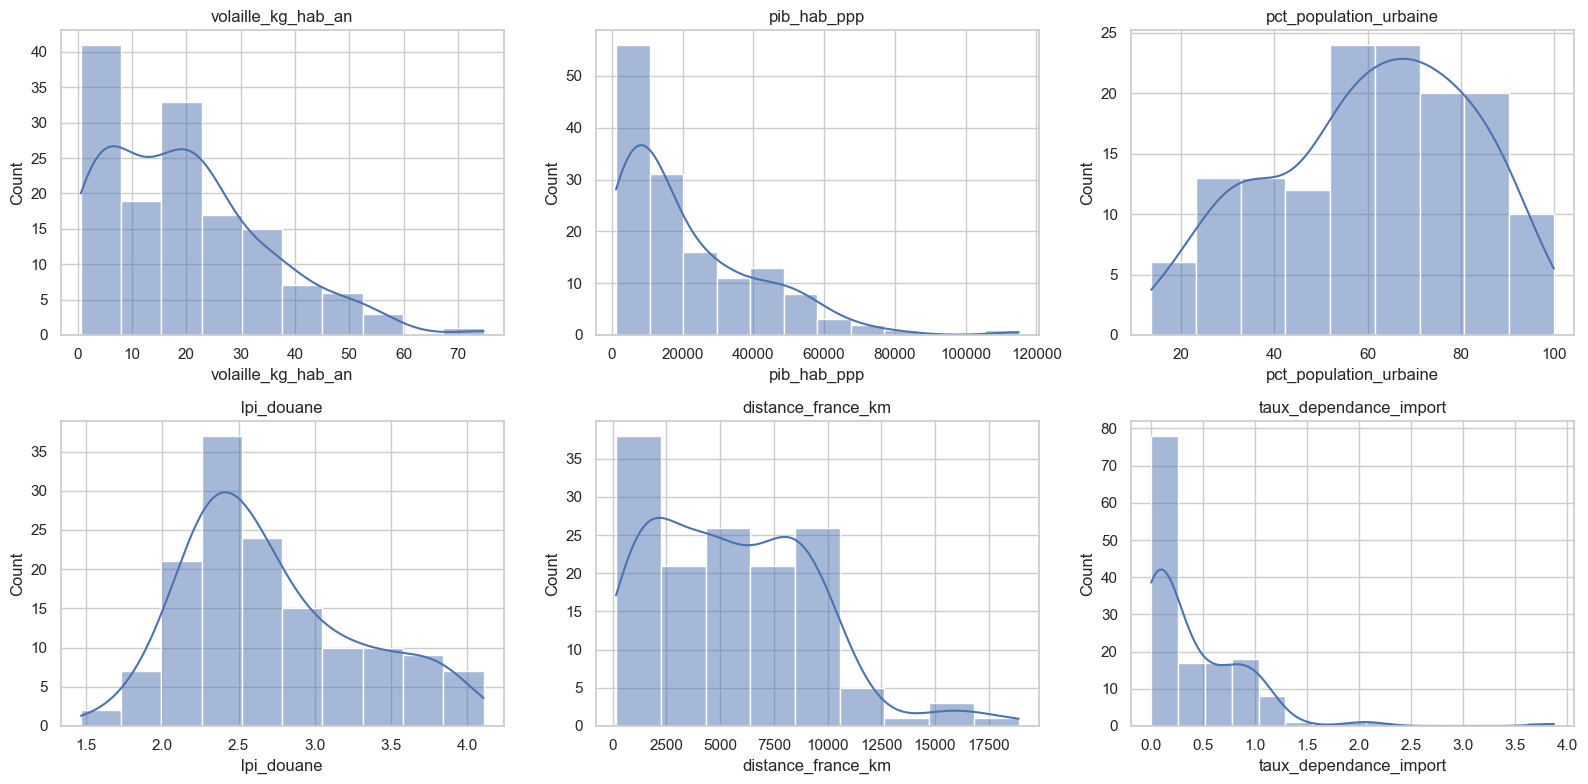

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols = [
    "volaille_kg_hab_an",
    "pib_hab_ppp",
    "pct_population_urbaine",
    "lpi_douane",
    "distance_france_km",
    "taux_dependance_import",
]
for ax, col in zip(axes.flat, cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()


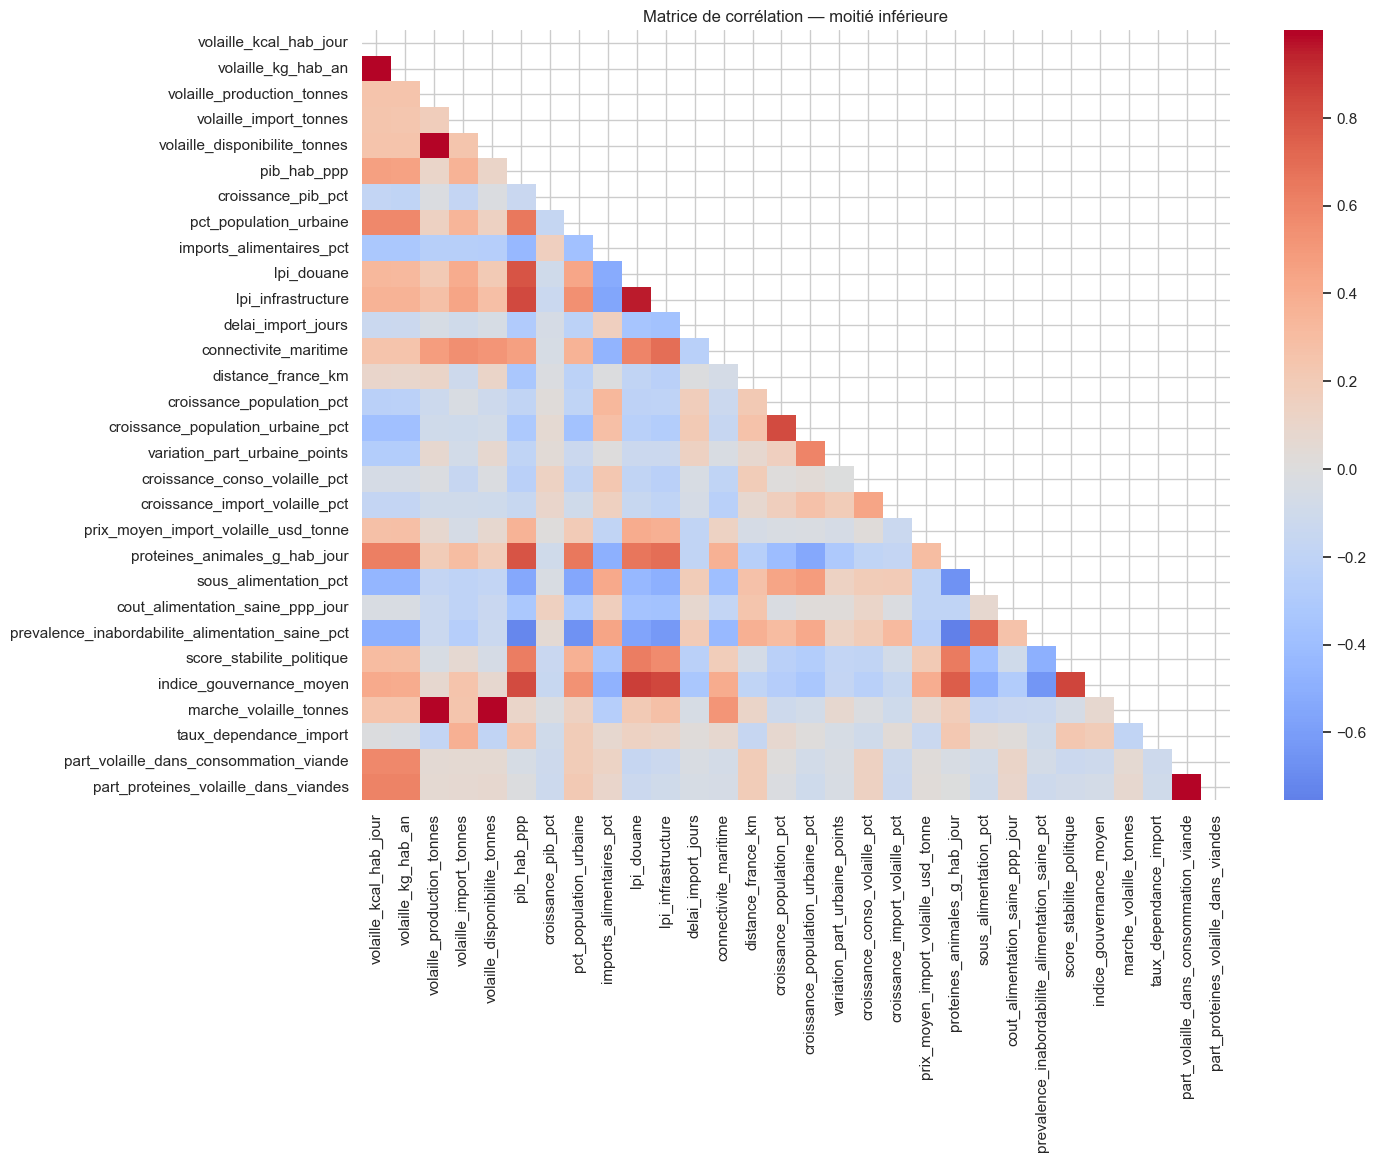

In [12]:
#corr = df[MODELING_FEATURES].corr()
#plt.figure(figsize=(14, 10))
#sns.heatmap(corr, cmap="coolwarm", center=0)
#plt.title("Matrice de corrélation — variables de modélisation")
#plt.show()


corr = df[MODELING_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Matrice de corrélation — moitié inférieure")
plt.show()

## 5. Pays à fort potentiel commercial brut


In [13]:
preview_cols = [
    "pays",
    "marche_volaille_tonnes",
    "pib_hab_ppp",
    "prix_moyen_import_volaille_usd_tonne",
    "taux_dependance_import",
    "croissance_conso_volaille_pct",
    "score_stabilite_politique",
]

df.sort_values(
    ["marche_volaille_tonnes", "pib_hab_ppp"],
    ascending=[False, False]
)[preview_cols].head(15)

,pays,marche_volaille_tonnes,pib_hab_ppp,prix_moyen_import_volaille_usd_tonne,taux_dependance_import,croissance_conso_volaille_pct,score_stabilite_politique
136,United States,"17,832,830.05","60,047.72","3,430.34",0.01,2.22,67.78
22,China,"17,745,892.65","15,022.44","2,283.42",0.03,-0.56,62.42
15,Brazil,"9,901,505.63","14,559.05","2,577.93",0.00,2.82,55.61
110,Russian Federation,"4,605,796.34","25,777.90","1,592.49",0.05,3.94,56.69
86,Mexico,"4,214,111.95","20,488.72","1,215.07",0.23,1.57,48.03
57,India,"3,793,444.15","6,144.72","3,988.06",0.00,7.49,56.12
135,United Kingdom,"2,194,029.16","46,113.02","2,847.92",0.35,2.84,73.42
59,"Iran, Islamic Rep.","2,189,438.92","15,719.42","1,428.90",0.00,1.30,53.95
119,South Africa,"2,115,786.80","13,738.44",865.94,0.24,0.37,59.36
58,Indonesia,"2,047,875.40","10,687.64","2,146.19",0.00,1.92,55.96


## 6. Export pour le notebook 2


In [14]:
output_path = ROOT / "outputs" / "dataset_p11.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
output_path


WindowsPath('D:/openclassroom/P11/outputs/dataset_p11.csv')